# SEE060: Lösning för Inlämningsuppgift 3

## Kod

In [1]:
import matplotlib.pyplot as plt
import numpy as np


START = 1989
END = 2300
INITIAL_MASS = 1e10  # kg
EMISSION = 4e8  # kg/year
RESIDENCE_TIME = 100  # year


def calc_mass(
    start_year,
    end_year,
    dt,
    initial_mass,
    emiss,
    residence_time,
    year_zero_emiss=None,
):
    years = np.arange(start_year, end_year + dt, dt)
    mass = np.zeros_like(years)
    mass[0] = initial_mass

    E = emiss

    for t, year in enumerate(years[:-1]):
        if year_zero_emiss is not None and year >= year_zero_emiss:
            E = 0

        mass[t + 1] = mass[t] + dt * (E - mass[t] / residence_time)

    return years, mass

## Fråga 1

### b) Visa att den numeriska lösningen ger samma jämviktsvärde

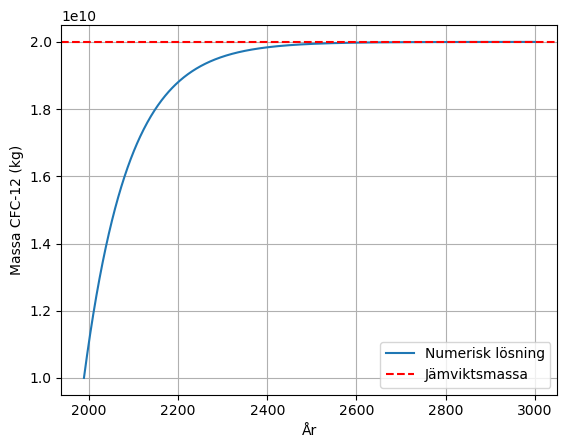

In [2]:
years, m = calc_mass(
    start_year=START,
    end_year=3000,
    dt=1,
    initial_mass=INITIAL_MASS,
    emiss=EMISSION/2,
    residence_time=RESIDENCE_TIME,
)

fig, ax = plt.subplots()
ax.plot(years, m, label="Numerisk lösning")
ax.axhline(2e10, color="r", linestyle="--", label="Jämviktsmassa")
ax.set_ylabel("Massa CFC-12 (kg)")
ax.set_xlabel("År")
ax.grid()
ax.legend()
fig.savefig("output/fraga1b.png")

## Fråga 2

### a) Skapa en plot som visar hur massan av CFC-12 förändras över tid

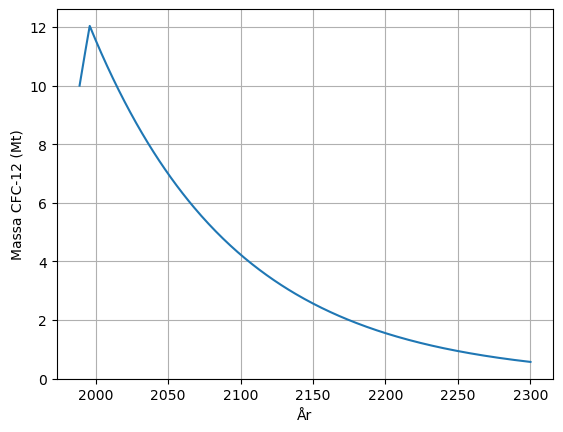

In [3]:
years, m = calc_mass(
    start_year=START,
    end_year=END,
    dt=1,
    initial_mass=INITIAL_MASS,
    emiss=EMISSION,
    residence_time=RESIDENCE_TIME,
    year_zero_emiss=1996,
)
m = m/1e9  # Mt

fig, ax = plt.subplots()
ax.plot(years, m)
ax.set_ylabel("Massa CFC-12 (Mt)")
ax.set_xlabel("År")
ax.grid()
fig.savefig("output/fraga2a.png")

### b) Vad är den maximala massan av CFC-12 i atmosfären?

In [4]:
print(f"Den maximala massan är {m.max():.2f} Mt.")

Den maximala massan är 12.04 Mt.


### c) Vilket år försvinner ozonhålet?

In [5]:
year_ozone_hole = years[m < 7][0]
print(f"Ozonhålet försvinner år {year_ozone_hole}.")

Ozonhålet försvinner år 2050.


### d) Vilket år är CFC-12 borta ur atmosfären?

In [6]:
year_cfc_gone = years[m < 1][0]
print(f"CFC-12 är borta ur atmosfären år {year_cfc_gone}.")

CFC-12 är borta ur atmosfären år 2244.


## Fråga 3

### a) Skapa en plot som visar hur massan av CFC-12 förändras över tid

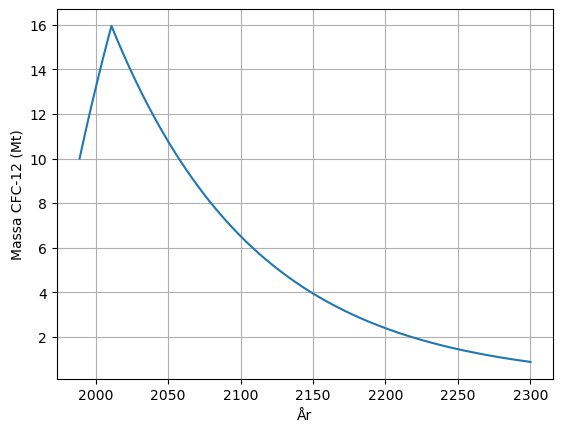

In [7]:
years_delayed, m_delayed = calc_mass(
    start_year=START,
    end_year=END,
    dt=1,
    initial_mass=INITIAL_MASS,
    emiss=EMISSION,
    residence_time=RESIDENCE_TIME,
    year_zero_emiss=2011,
)
m_delayed = m_delayed/1e9  # Mt

fig, ax = plt.subplots()
ax.plot(years_delayed, m_delayed)
ax.set_ylabel("Massa CFC-12 (Mt)")
ax.set_xlabel("År")
ax.grid()
fig.savefig("output/fraga3a.png")

### b) Vad är den maximala massan av CFC-12 i atmosfären?

In [8]:
print(f"Den maximala massan är {m_delayed.max():.2f} Mt.")

Den maximala massan är 15.95 Mt.


### c) Vilket år försvinner ozonhålet?

In [9]:
year_ozone_hole_delayed = years_delayed[m_delayed < 7][0]
print(f"Ozonhålet försvinner år {year_ozone_hole_delayed}.")

Ozonhålet försvinner år 2093.


### d) Vilket år är CFC-12 borta ur atmosfären?

In [10]:
year_cfc_gone_delayed = years_delayed[m_delayed < 1][0]
print(f"CFC-12 är borta ur atmosfären år {year_cfc_gone_delayed}.")

CFC-12 är borta ur atmosfären år 2287.


### e) Vilken effekt hade en försening av Montrealprotokollet på 15 år fått?

In [11]:
print(f"Difference in peak concentration: {m_delayed.max() - m.max():.2f} Mt.")
print(f"Relative difference in peak concentration: {(m_delayed.max() - m.max())/m.max() * 100:.2f}%.")
print(f"Ozone hole delay: {year_ozone_hole_delayed - year_ozone_hole} years.")
print(f"CFC-12 gone delay: {year_cfc_gone_delayed - year_cfc_gone} years.")

Difference in peak concentration: 3.91 Mt.
Relative difference in peak concentration: 32.51%.
Ozone hole delay: 43 years.
CFC-12 gone delay: 43 years.
